# Inference Time Study

In [1]:
################################################## Initialize ##################################################

# Add the new path
import sys
new_path = "/home/michele/code/michele_mmdet3d/"
if not new_path in sys.path:
    sys.path.insert(1, new_path)



############################################# Time-related variables #############################################
import torch
if not torch.cuda.is_available():
    raise MemoryError("\t\tCUDA not available: exiting...\n\n\n")

In [2]:
############################################### Generic Parameters ###############################################

# Boolean to print inputs/outputs of each stage
wanna_print_in_out = False

# Home directory within ADE
home_dir = '/home/michele/code/'

# Relative path from "home_dir" to the .bin files
path_from_home_to_bin_files = "michele_mmdet3d/data/minerva_polimove_cones/training/velodyne"
# Path to the ".txt" file in "ImageSets", containing the list of validation files
val_list_txt_file = "/home/michele/code/michele_mmdet3d/data/minerva_polimove_cones/ImageSets/val.txt"
# Path to the .pkl file for the validation dataset (saved during create_data.py)
pkl_info_file = "/home/michele/code/michele_mmdet3d/data/minerva_polimove_cones/minerva_polimove_cones_infos_val.pkl"

# Boolean to choose the type of model ("TensorRT" or "PyTorch")
# model_type = "Tensor-RT"
model_type = "PyTorch"



############################################# Configuration Parameters #############################################



# # Case 0: PointPillars
# #         HardVoxelization  (Deterministic or Non-Deterministic voxelization can be chosen in the config)
# #         TRT
# #         (@ epoch 61)
# # 
# mmdet3d_cfg = home_dir + 'michele_mmdet3d/configs/minerva/CONDENSED-HARD_pointpillars_minerva.py'
# # Specific for Tensor-RT
# if model_type == "Tensor-RT":
#     deploy_cfg = home_dir + 'mmdeploy/configs/mmdet3d/voxel-detection/voxel-detection_tensorrt_dynamic-kitti-32x4.py'
#     engine_files = [ home_dir + 'Presentation_results/PPillars_Checkpoints/PPillars_HardVox/mmdeploy_model/PointPillars_Hard.engine' ]
#     reference_img = home_dir + 'auto-labeling/data/Databases/Merged_Fusion_DataSet/MMDetection3D Version "Whole PCD No Images"/training/velodyne/1722779447121733104.bin'
# # Specific for PyTorch
# if model_type == "PyTorch":
#     weights = home_dir + 'Presentation_results/PPillars_Checkpoints/PPillars_HardVox/Checkpoints/epoch_61.pth'



# # Case 1: PointPillars
# #         DynamicVoxelization 
# #         (@ epoch 57)
# # 
# mmdet3d_cfg = home_dir + 'michele_mmdet3d/configs/minerva/CONDENSED-DYNAMIC_pointpillars_minerva.py'
# # Specific for Tensor-RT
# if model_type == "Tensor-RT":
#     deploy_cfg = home_dir + ''
#     engine_files = [ home_dir + '' ]
#     reference_img = home_dir + ''
# # Specific for PyTorch
# if model_type == "PyTorch":
#     weights = home_dir + 'Presentation_results/PPillars_Checkpoints/PPillars_DynamicVox/Checkpoint/epoch_57.pth'



# Case 2: Cone-Shaped
#         DynamicVoxelization
#         (@ epoch 110)
# 
mmdet3d_cfg = home_dir + 'michele_mmdet3d/configs/minerva/CONE-SHAPED-DYNAMIC_pointpillars_minerva.py'
# Specific for Tensor-RT
if model_type == "Tensor-RT":
    deploy_cfg = home_dir + ''
    engine_files = [ home_dir + '' ]
    reference_img = home_dir + ''
# Specific for PyTorch
if model_type == "PyTorch":
    weights = home_dir + 'Presentation_results/PPillars_Checkpoints/Cone-Shaped_DynamicVox/Checkpoints/epoch_110.pth'

In [3]:
################################################ Create the model ################################################
from mmdeploy.apis.inference import get_model
from mmdet3d.apis import LidarDet3DInferencer



if model_type == "Tensor-RT":
    # Build the model with the built-in function of MMDeploy
    model = get_model(
        model_cfg= mmdet3d_cfg,
        deploy_cfg= deploy_cfg,
        backend_files= engine_files,
        img= reference_img,
        device='cuda')
    model_cfg = model.model_cfg
    # Set the "save_losses_on_file" to False
    model.save_losses_on_file = False

elif model_type == "PyTorch":
    # Get the model from the inferencer
    inferencer = LidarDet3DInferencer(model= mmdet3d_cfg,
                                      weights= weights,
                                      device= 'cuda',
                                      show_progress=False)
    model_cfg = inferencer.cfg
    model = inferencer.model
    # Set the "save_losses_on_file" to False
    model.save_losses_on_file = False



# Build the additional BBoxHead (for PointPillars)
from mmengine.registry import MODELS
bbox_head = MODELS.build(model_cfg.model).bbox_head.to('cuda:0')

/home/michele/code/michele_mmdet3d/mmdet3d/models/dense_heads/anchor3d_head.py:94: UserWarning: dir_offset and dir_limit_offset will be depressed and be incorporated into box coder in the future
  warnings.warn(


Loads checkpoint by local backend from path: /home/michele/code/Presentation_results/PPillars_Checkpoints/Cone-Shaped_DynamicVox/Checkpoints/epoch_110.pth
03/01 22:51:50 - mmengine - WARNING - Failed to search registry with scope "mmdet3d" in the "function" registry tree. As a workaround, the current "function" registry in "mmengine" is used to build instance. This may cause unexpected failure when running the built modules. Please check whether "mmdet3d" is a correct scope, or whether the registry is initialized.
Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


/usr/local/lib/python3.10/dist-packages/mmengine/visualization/visualizer.py:196: UserWarning: Failed to add <class 'mmengine.visualization.vis_backend.LocalVisBackend'>, please provide the `save_dir` argument.
  warnings.warn(f'Failed to add {vis_backend.__class__}, '
/home/michele/code/michele_mmdet3d/mmdet3d/models/dense_heads/anchor3d_head.py:94: UserWarning: dir_offset and dir_limit_offset will be depressed and be incorporated into box coder in the future
  warnings.warn(


In [4]:
############################################### Automatic configs ###############################################

config_dictionary = {}

# For the loader
config_dictionary['LoadPointsFromFile'] = {
    'coord_type': model_cfg.val_dataloader.dataset.pipeline[0].coord_type,
    'load_dim': model_cfg.val_dataloader.dataset.pipeline[0].load_dim,
    'use_dim': model_cfg.val_dataloader.dataset.pipeline[0].use_dim
}

# For the Det3DDataPreprocessor
config_dictionary['Det3DDataPreprocessor'] = {
    'voxel': model_cfg.model.data_preprocessor.voxel,
    'voxel_layer': dict(
        max_num_points = model_cfg.model.data_preprocessor.voxel_layer.max_num_points,
        max_voxels = model_cfg.model.data_preprocessor.voxel_layer.max_voxels,
        point_cloud_range = model_cfg.model.data_preprocessor.voxel_layer.point_cloud_range,
        voxel_size = model_cfg.model.data_preprocessor.voxel_layer.voxel_size
    ),
    'voxel_type': model_cfg.model.data_preprocessor.voxel_type
}

# For the BBoxHead (which needs the test configuration)
config_dictionary['test_cfg'] = model_cfg['model']['test_cfg']

In [ ]:
############################################### Very original input ###############################################

# Read the names of the validation files from the ".txt" file in "ImageSets"
with open(val_list_txt_file, 'r') as file:
    val_file_names = [line.strip()+".bin" for line in file]



# Create the inputs
#   - List of strings
#   - Each string is the ABSOLUTE path to the ".bin" file
inputs = []
for file_name in val_file_names:
    inputs.append(home_dir+path_from_home_to_bin_files+"/"+file_name)



# Print the output of this stage
if wanna_print_in_out:
    print("\nStarting values:")
    for element in inputs:
        print(element)

In [6]:
############################################### LoadPointsFromFile ###############################################

from mmdet3d.datasets.transforms.loading import LoadPointsFromFile

# Initialize the loader
loader = LoadPointsFromFile(
    coord_type=config_dictionary['LoadPointsFromFile']['coord_type'],
    load_dim=config_dictionary['LoadPointsFromFile']['load_dim'],
    use_dim=config_dictionary['LoadPointsFromFile']['use_dim']
)

# Print the input to this stage
if wanna_print_in_out:
    print("\nLoadPointsFromFile input:")
    for element in inputs:
        print(element)



# For cycle to also handle lists of inputs
for i in range(len(inputs)):
    
    # Prepare the string input for the loader (needs two dictionaries, one nested into the other)
    inputs[i] = dict(
        lidar_points=dict(
            lidar_path=inputs[i]
        )
    )

    # Actual modification of the dictionary
    loader(inputs[i])



# Print the output of this stage
if wanna_print_in_out: 
    print("\nLoadPointsFromFile output:")
    for element in inputs:
        print(element)

In [7]:
############################################### Add METAINFO ###############################################

import mmengine
from mmdet3d.structures.bbox_3d import Box3DMode, LiDARInstance3DBoxes

# Print the input of this stage
if wanna_print_in_out: 
    print("\nBefore adding metainfos:")
    for element in inputs:
        print(element)

# Get the METAINFO from the .pkl file
info_list = mmengine.load(pkl_info_file)['data_list']



# Check the format of info_list, and make it match inputs
new_info_list = []
if not len(info_list) == len(inputs):
    # Copied from MultiModalityDet3DInferencer._inputs_to_list()
    for element in inputs:
        timestamp = element['img_path'].split('/')[-1].split('.')[0]
        for element in info_list:
            if str(element['sample_idx']) == str(timestamp):
                new_info_list.append(element)
    # Update the field "info_list"    
    info_list = new_info_list



# Get the right fields
for index, input in enumerate(inputs):
    data_info = info_list[index]
    input['box_mode_3d'] = Box3DMode.LIDAR
    input['box_type_3d'] = LiDARInstance3DBoxes

    # Added part for the addition of BBoxes
    input['gt_bboxes_3d'] = [data_info['instances'][0]['bbox_3d']]
    input['gt_labels_3d'] = data_info['instances'][0]['bbox_label']

# Print the output of this stage
if wanna_print_in_out: 
    print("\nAfter adding metainfos:")
    for element in inputs:
        print(element)

In [8]:
############################################### Pack3DDetInputs ###############################################

from mmdet3d.datasets.transforms.formating import Pack3DDetInputs

# Initialize the packer
packer = Pack3DDetInputs(keys=['points', 'gt_bboxes_3d', 'gt_labels_3d'])

# Print the input to this stage
if wanna_print_in_out: 
    print("\nPack3DDetInputs input:")
    for element in inputs:
        print(element)



# For cycle to also handle lists of inputs
for i in range(len(inputs)):

    # Actual modification of the dictionary
    inputs[i] = packer(inputs[i])



# Print the output of this stage
if wanna_print_in_out: 
    print("\nPack3DDetInputs output:")
    for element in inputs:
        print(element)

In [9]:
############################################### Det3DDataPreprocessor ###############################################

from mmdet3d.models.data_preprocessors.data_preprocessor import Det3DDataPreprocessor

# Initialize the preprocessor
preprocessor = Det3DDataPreprocessor(
    voxel=config_dictionary['Det3DDataPreprocessor']['voxel'],
    voxel_layer=config_dictionary['Det3DDataPreprocessor']['voxel_layer'],
    voxel_type=config_dictionary['Det3DDataPreprocessor']['voxel_type']
)

# Print the input to this stage
if wanna_print_in_out: 
    print("\nDet3DDataPreprocessor input:")
    for element in inputs:
        print(element)



# Create the list with the final inputs
final_inputs = []
for i in range(len(inputs)):    

    # Create a temporary dictionary to be passed to the preprocessor (in the right format)
    temp = {
        'data_samples': [inputs[i]['data_samples']],
        'inputs': inputs[i]['inputs']}
    temp['inputs']['points'] = [inputs[i]['inputs']['points']]

    # Take out the result of the Det3DDataPreprocessor
    final_inputs.append(
        preprocessor(temp))



# Print the output of this stage
if wanna_print_in_out: 
    print("\nDet3DDataPreprocessor output:")
    for element in final_inputs:
        print(element)

In [10]:
################################################# Compute losses #################################################

losses=[]
for element in final_inputs:

    # Move the tensors to the right device
    # Standard ones
    element['inputs']['points'][0] = element['inputs']['points'][0].to('cuda:0')
    element['inputs']['voxels']['voxels'] = element['inputs']['voxels']['voxels'].to('cuda:0')
    element['inputs']['voxels']['coors'] = element['inputs']['voxels']['coors'].to('cuda:0')
    # Added ones for losses
    if len(element['data_samples']) == 1:
        element['data_samples'][0].gt_instances_3d.bboxes_3d = element['data_samples'][0].gt_instances_3d.bboxes_3d.to('cuda:0')
        element['data_samples'][0].gt_instances_3d.labels_3d = element['data_samples'][0].gt_instances_3d.labels_3d.to('cuda:0')
    else:
        print("\t\tError! New UNFORESEEN situation just found...\n\n\n")
        exit()

    # Do the forward pass to obtain the raw data
    raw_results = model(element['inputs'], mode='tensor')

    # Unpack the raw data
    if model_type == "Tensor-RT":
        cls_score = raw_results['cls_score']
        bbox_pred = raw_results['bbox_pred']
        dir_cls_pred = raw_results['dir_cls_pred']
    elif model_type == "PyTorch":
        cls_score = raw_results[0]
        bbox_pred = raw_results[1]
        dir_cls_pred = raw_results[2]

    # Compute the losses
    loss_dict = bbox_head.loss_by_feat(
            cls_scores = cls_score,
            bbox_preds = bbox_pred,
            dir_cls_preds = dir_cls_pred,
            batch_gt_instances_3d = [element['data_samples'][0].gt_instances_3d],
            batch_input_metas = [element['data_samples'][0].metainfo])

    # # NOTE: Different option to compute losses 
    # #   --> "Standard" way with the inferencer
    # #   --> Does NOT work with Tensor-RT
    # loss_dict = model.loss(element['inputs'], element['data_samples'])

    losses.append({
        'loss_cls': float(loss_dict['loss_cls'][0]),
        'loss_bbox': float(loss_dict['loss_bbox'][0]),
        'loss_dir': float(loss_dict['loss_dir'][0]),
        'total_loss': float(loss_dict['loss_cls'][0]) + float(loss_dict['loss_bbox'][0]) + float(loss_dict['loss_dir'][0])
    })

    loss_dict = raw_results = element = cls_score = bbox_pred = dir_cls_pred = None

/usr/local/lib/python3.10/dist-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/usr/local/lib/python3.10/dist-packages/mmdet/models/task_modules/samplers/sampling_result.py:132: UserWarning: DeprecationWarning: pos_bboxes is deprecated, please use "pos_priors" instead
  warnings.warn('DeprecationWarning: pos_bboxes is deprecated, '


In [11]:
#################################################################################################################
#                                              PREPARE THE LISTS                                                #
#################################################################################################################

from plotters import *

# Create the lists
losses_cls = []
losses_bbox = []
losses_dir = []
losses_total = []

# Assign the values
for element in losses:
    losses_cls.append(element['loss_cls'])
    losses_bbox.append(element['loss_bbox'])
    losses_dir.append(element['loss_dir'])
    losses_total.append(element['total_loss'])

# Check that the vectors are all of the same dimension
if len(losses_cls) != len(losses_bbox) or len(losses_cls) != len(losses_dir) or len(losses_cls) != len(losses_total):
    print("\nWrong dimensions for lists!!!\n")
    exit()

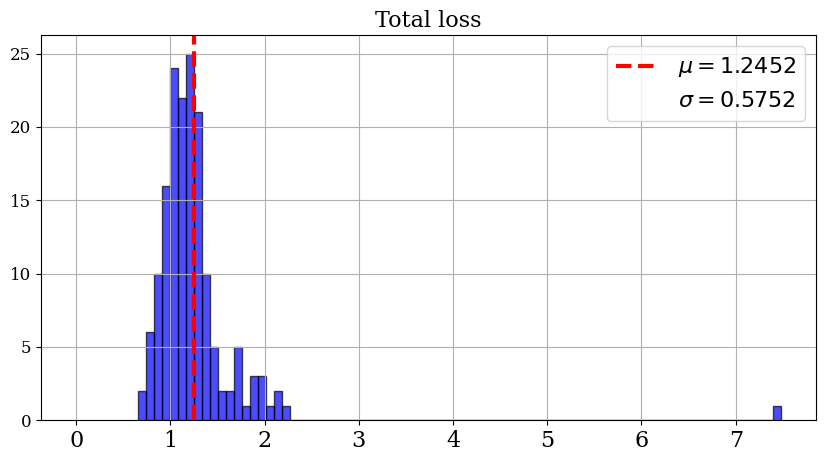

In [12]:
# Plot the total loss

freq_plot_with_variance(losses_total, "Total loss", "blue", 80)

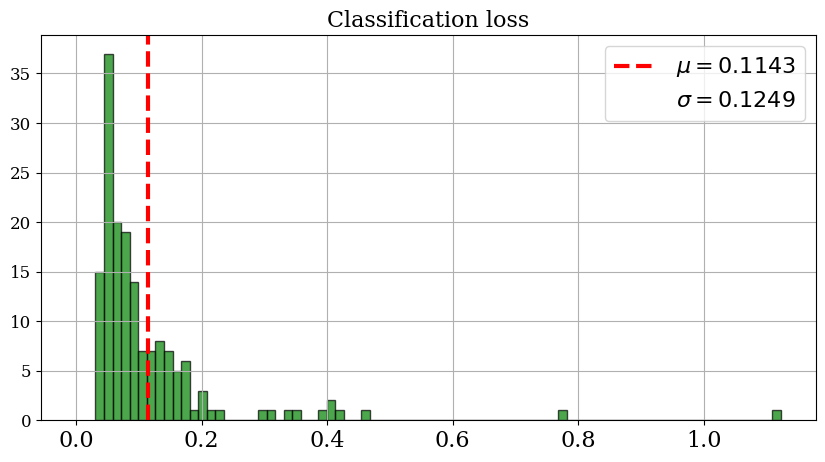

In [13]:
# Plot the classification loss

freq_plot_with_variance(losses_cls, "Classification loss", "green", 80)

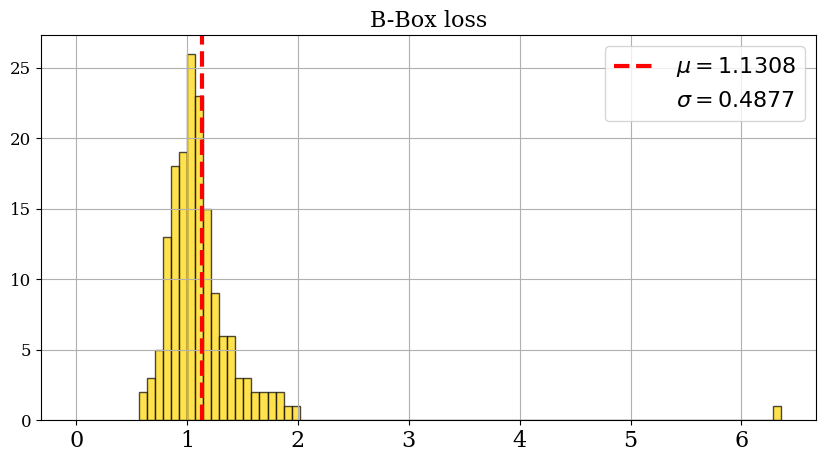

In [14]:
#Plot the bbox loss

freq_plot_with_variance(losses_bbox, "B-Box loss", "gold", 80)

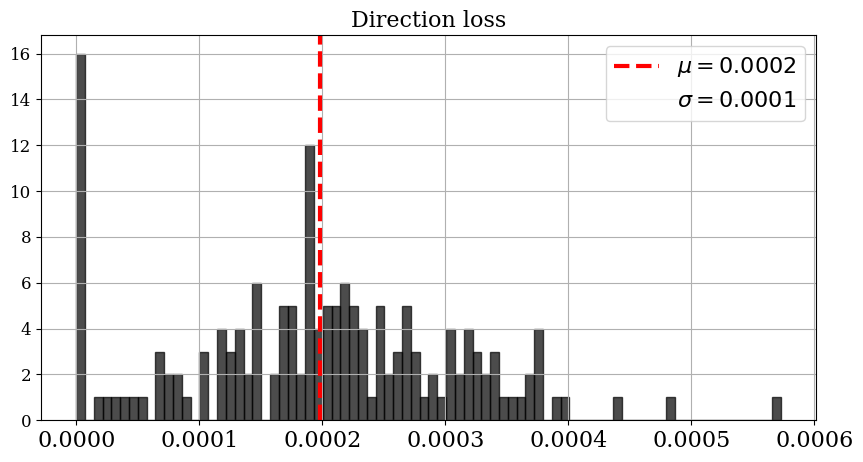

In [15]:
#Plot the direction loss

freq_plot_with_variance(losses_dir, "Direction loss", "black", 80)

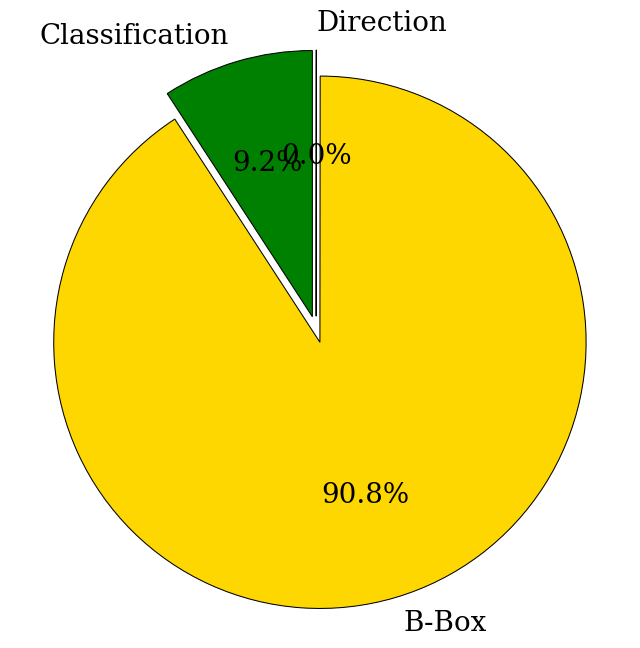

In [16]:
# Plot the pie chart with the percentages

plot_pie_chart(losses_cls, losses_bbox, losses_dir, "Classification", "B-Box", "Direction")